# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Load Dataset

In [ ]:
df = pd.read_csv("/content/data_ecommerce_customer_churn.csv")

df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


# Exploratory Data Analysis

In [ ]:
df.describe()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
count,3941.000000,3941.000000,3941.000000,3941.000000,3941.000000,3941.000000,3941.000000,3941.000000,3941.000000,3941.000000,3941.000000
mean,10.028165,15.579802,3.679269,2.362091,3.088302,1.186247,4.237757,0.282416,4.448871,176.707419,0.171023
std,8.290290,8.275800,1.013938,1.408305,1.381832,0.666321,2.626699,0.450232,3.583909,48.791784,0.376576
min,0.000000,5.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,9.000000,3.000000,2.000000,2.000000,1.000000,2.000000,0.000000,2.000000,145.700000,0.000000
50%,9.000000,14.000000,4.000000,2.000000,3.000000,1.000000,3.000000,0.000000,3.000000,163.340000,0.000000
75%,15.000000,20.000000,4.000000,4.000000,4.000000,2.000000,6.000000,1.000000,7.000000,195.250000,0.000000
max,61.000000,127.000000,6.000000,5.000000,5.000000,2.000000,22.000000,1.000000,46.000000,324.990000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


Mengidentikasi Outlier

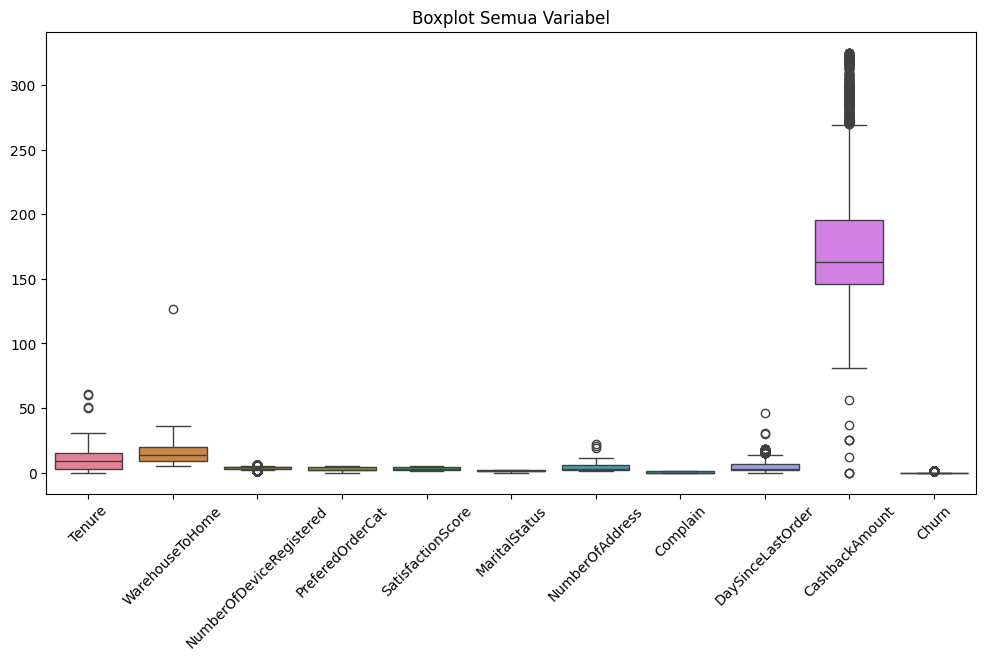

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot Semua Variabel")
plt.show()

Berdasarkan boxplot seluruh variabel, terlihat bahwa hampir semua variabel numerik mengandung outlier dengan jumlah yang cukup signifikan. Hal ini menunjukkan bahwa distribusi data pada dataset tidak normal dan cenderung memiliki nilai ekstrem.

Cek Missing Value

In [ ]:
print(df.isnull().sum())

Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64


Beberapa variabel pada dataset ini memiliki jumlah *missing value* yang cukup banyak, yaitu variabel Tenure sebanyak 194 data, variabel WarehouseToHome sebanyak 169 data, dan variabel DaySinceLastOrder sebanyak 213 data.

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

Kemudian dilakukan penanganan terhadap variabel yang mengandung *missing value* dengan menginput nilai median pada masing-masing variabel. Nilai median dipilih sebagai karena bersifat lebih robust terhadap *outlier* yang terkandung pada variabel dataset.

Menangani Missing Value

In [ ]:
print(df.isnull().sum())

Tenure                      0
WarehouseToHome             0
NumberOfDeviceRegistered    0
PreferedOrderCat            0
SatisfactionScore           0
MaritalStatus               0
NumberOfAddress             0
Complain                    0
DaySinceLastOrder           0
CashbackAmount              0
Churn                       0
dtype: int64


# Encoding Data Kategorikal

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['PreferedOrderCat'] = le.fit_transform(df['PreferedOrderCat'])
df['MaritalStatus'] = le.fit_transform(df['MaritalStatus'])

Variabel yang masih berbentuk object (PreferedOrderCat, dan MaritalStatus) di encoding agar berbentuk angka sehingga dapat dianalisis.

In [ ]:
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,2,3,2,2,0,7.0,143.32,0
1,7.0,25.0,4,3,1,1,2,0,7.0,129.29,0
2,27.0,13.0,3,2,1,1,5,0,7.0,168.54,0
3,20.0,25.0,4,0,3,0,7,0,3.0,230.27,0
4,30.0,15.0,4,5,4,2,8,0,8.0,322.17,0


# Feature & Target

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

Variabel independen (feature) diperoleh dengan menghilangkan kolom Churn dari dataset, sedangkan variabel dependen (target) adalah kolom Churn yang menunjukkan apakah pelanggan melakukan churn atau tidak.

# Split Data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Seluruh dataset distandarisasi agar memiliki skala yang sama sehingga hasil model KNN dan  Logistic Regression dapat akurat.

# Regresi Logistik

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)

# pakai data yang sudah di-scale
logreg.fit(X_train_scaled, y_train)

y_pred_logreg = logreg.predict(X_test_scaled)
y_prob_logreg = logreg.predict_proba(X_test_scaled)[:,1]

Evaluasi Regresi Logistik

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("ROC AUC:", roc_auc_score(y_test, y_prob_logreg))
print(classification_report(y_test, y_pred_logreg))

Logistic Regression
Accuracy: 0.8669201520912547
ROC AUC: 0.8673802242609582
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       654
           1       0.70      0.39      0.50       135

    accuracy                           0.87       789
   macro avg       0.79      0.68      0.71       789
weighted avg       0.85      0.87      0.85       789



Model Logistic Regression memiliki accuracy sebesar 0,867 dan ROC AUC 0,867, yang menunjukkan performa klasifikasi yang cukup baik. Model sangat baik dalam mengidentifikasi pelanggan yang tidak churn (recall 0,96), namun kurang optimal dalam mendeteksi pelanggan yang churn (recall 0,39).

Confusion Matrix

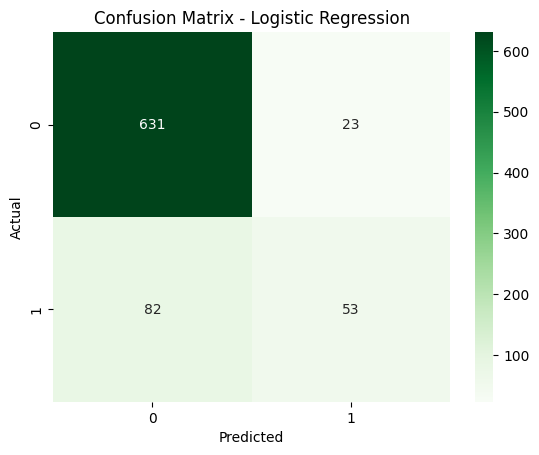

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_logreg = confusion_matrix(y_test, y_pred_logreg)

sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Model berhasil mengklasifikasikan 631 data tidak churn dengan benar (TN) dan 53 data churn dengan benar (TP). Namun, terdapat 82 data churn yang salah diprediksi sebagai tidak churn (FN) dan 23 data tidak churn yang salah diprediksi sebagai churn (FP). Hal ini menunjukkan model masih cukup sering gagal mendeteksi pelanggan yang churn.

# K-Nearest Neighbors

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

Evaluasi KNN

In [ ]:
print("KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN
Accuracy: 0.8859315589353612
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       654
           1       0.77      0.47      0.59       135

    accuracy                           0.89       789
   macro avg       0.84      0.72      0.76       789
weighted avg       0.88      0.89      0.87       789



Model KNN memiliki accuracy sebesar 0,886, yang menunjukkan performa klasifikasi yang baik. Model sangat baik dalam mengidentifikasi pelanggan tidak churn (recall 0,97), namun masih kurang optimal dalam mendeteksi pelanggan churn (recall 0,47).

Confusion Matrix

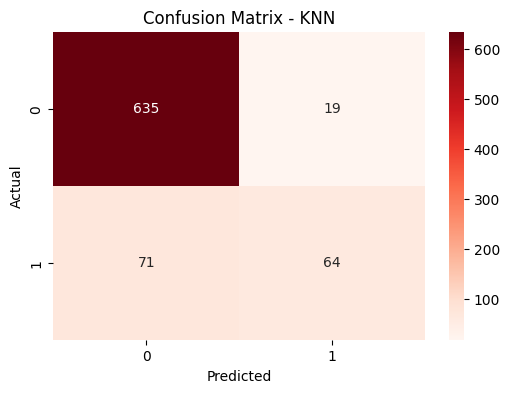

In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Model KNN berhasil mengklasifikasikan 635 data tidak churn dengan benar (TN) dan 64 data churn dengan benar (TP). Namun, masih terdapat 71 data churn yang salah diprediksi sebagai tidak churn (FN) dan 19 data tidak churn yang salah diprediksi sebagai churn (FP).

# Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

Evaluasi

In [ ]:
print("Naive Bayes")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes
Accuracy: 0.8580481622306717
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       654
           1       0.58      0.59      0.59       135

    accuracy                           0.86       789
   macro avg       0.75      0.75      0.75       789
weighted avg       0.86      0.86      0.86       789



Model Naive Bayes memiliki accuracy sebesar 0,858, yang menunjukkan performa yang cukup baik. Model mampu mengidentifikasi pelanggan tidak churn dengan baik (recall 0,91), dan memiliki kemampuan yang lebih seimbang dalam mendeteksi pelanggan churn (recall 0,59) dibanding model sebelumnya.

Confusion Matrix

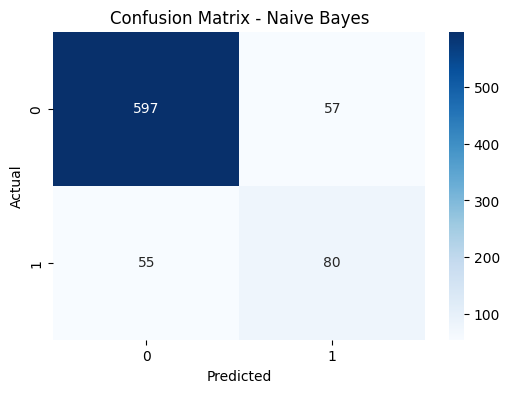

In [ ]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

Model Naive Bayes berhasil mengklasifikasikan 597 data tidak churn dengan benar (TN) dan 80 data churn dengan benar (TP). Namun, terdapat 55 data churn yang salah diprediksi sebagai tidak churn (FN) dan 57 data tidak churn yang salah diprediksi sebagai churn (FP).

# Perbandingan Ketiga Model

In [ ]:
# Logistic Regression
acc_log = accuracy_score(y_test, y_pred_logreg)
prec_log = precision_score(y_test, y_pred_logreg)
rec_log = recall_score(y_test, y_pred_logreg)
f1_log = f1_score(y_test, y_pred_logreg)
roc_log = roc_auc_score(y_test, y_prob_logreg)

# KNN
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

# Naive Bayes
acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb)
rec_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Naive Bayes'],
    'Accuracy': [acc_log, acc_knn, acc_nb],
    'Precision': [prec_log, prec_knn, prec_nb],
    'Recall': [rec_log, rec_knn, rec_nb],
    'F1-Score': [f1_log, f1_knn, f1_nb],
    'ROC-AUC': [roc_log, None, None]  # KNN & NB tidak dihitung di sini
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1-Score  ROC-AUC
0  Logistic Regression  0.866920   0.697368  0.392593  0.502370  0.86738
1                  KNN  0.885932   0.771084  0.474074  0.587156      NaN
2          Naive Bayes  0.858048   0.583942  0.592593  0.588235      NaN


Berdasarkan tabel perbandingan, model KNN memiliki accuracy tertinggi (0,886), sehingga paling baik dalam prediksi secara keseluruhan. Namun, dalam mendeteksi pelanggan churn (recall), Naive Bayes memiliki nilai tertinggi (0,593), sehingga lebih baik dalam mengidentifikasi pelanggan yang berpotensi churn. Sementara itu, Logistic Regression memiliki nilai ROC-AUC tertinggi (0,867), tetapi performanya paling rendah dalam mendeteksi churn (recall 0,393), sehingga kurang optimal untuk kasus ini.

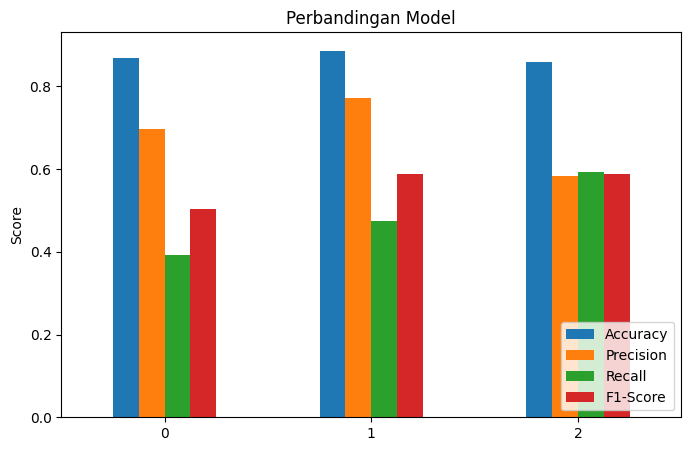

In [ ]:
import matplotlib.pyplot as plt

comparison[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(8,5))
plt.title("Perbandingan Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

Visualisasi tersebut menunjukkan perbandingan performa tiga model berdasarkan empat metrik evaluasi. KNN memiliki nilai accuracy dan precision tertinggi, sehingga paling baik dalam prediksi secara keseluruhan dan ketepatan prediksi churn. Namun, Naive Bayes memiliki nilai recall tertinggi, sehingga lebih unggul dalam mendeteksi pelanggan yang benar-benar churn. Sementara itu, Logistic Regression memiliki performa yang cukup baik, tetapi cenderung lebih rendah dalam recall, sehingga kurang optimal dalam mengidentifikasi pelanggan churn.